project: Time Series Forecasting

Dataset: airline-passengers.csv

To model and forecast monthly airline passenger demand using historical data to understand long term growth and recurring seasonal travel patterns

**Time series forecasting** predicts future values by learning patterns like trend and seasonality from historical, time ordered data. Unlike regular ML, the order of data matters, and past values directly influence future predictions.

**1. Setup**

In [1]:
# Installing the dependencies
%pip install -q pandas numpy matplotlib seaborn statsmodels scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# importing the required dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller  # perform specific test to understand the data
from statsmodels.tsa.seasonal import seasonal_decompose  # to understand the seasonality present in the data
from statsmodels.tsa.arima.model import ARIMA  # model to train

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error, 
    root_mean_squared_error
)


**2. Load data**

In [2]:
df = pd.read_csv("airline-passengers.csv")

In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (144, 2)


In [4]:
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [5]:
display(df.tail(10))

,Month,Passengers
134,1960-03,419
135,1960-04,461
136,1960-05,472
137,1960-06,535
138,1960-07,622
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


In [7]:
# Basic Dataset info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Month       144 non-null    str  
 1   Passengers  144 non-null    int64
dtypes: int64(1), str(1)
memory usage: 2.4 KB


In [8]:
# check missing values
df.isnull().sum()

Month         0
Passengers    0
dtype: int64

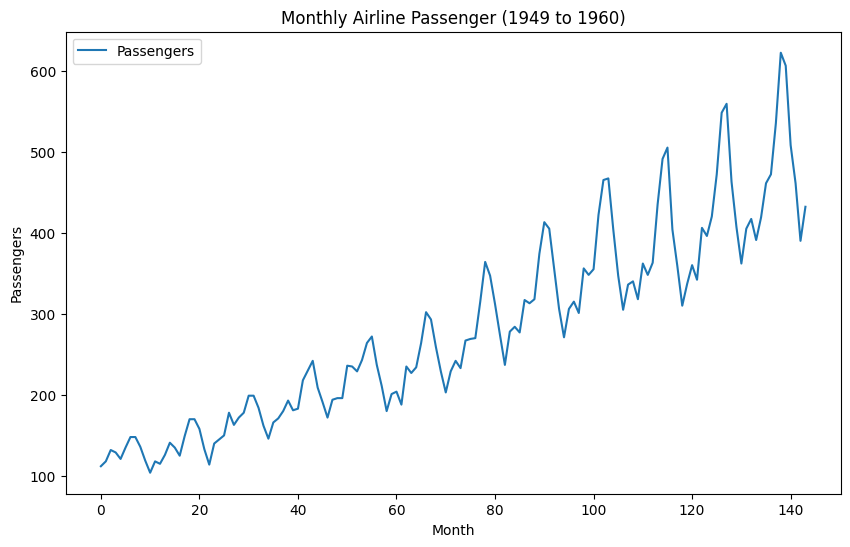

In [10]:
# Distribution of passenger
plt.figure(figsize=(10,6))
plt.plot(df["Passengers"], label="Passengers")
plt.title("Monthly Airline Passenger (1949 to 1960)")
plt.ylabel("Passengers")
plt.xlabel("Month")
plt.legend()
plt.show()

>Inference: Seasonality is clearly visible in the data

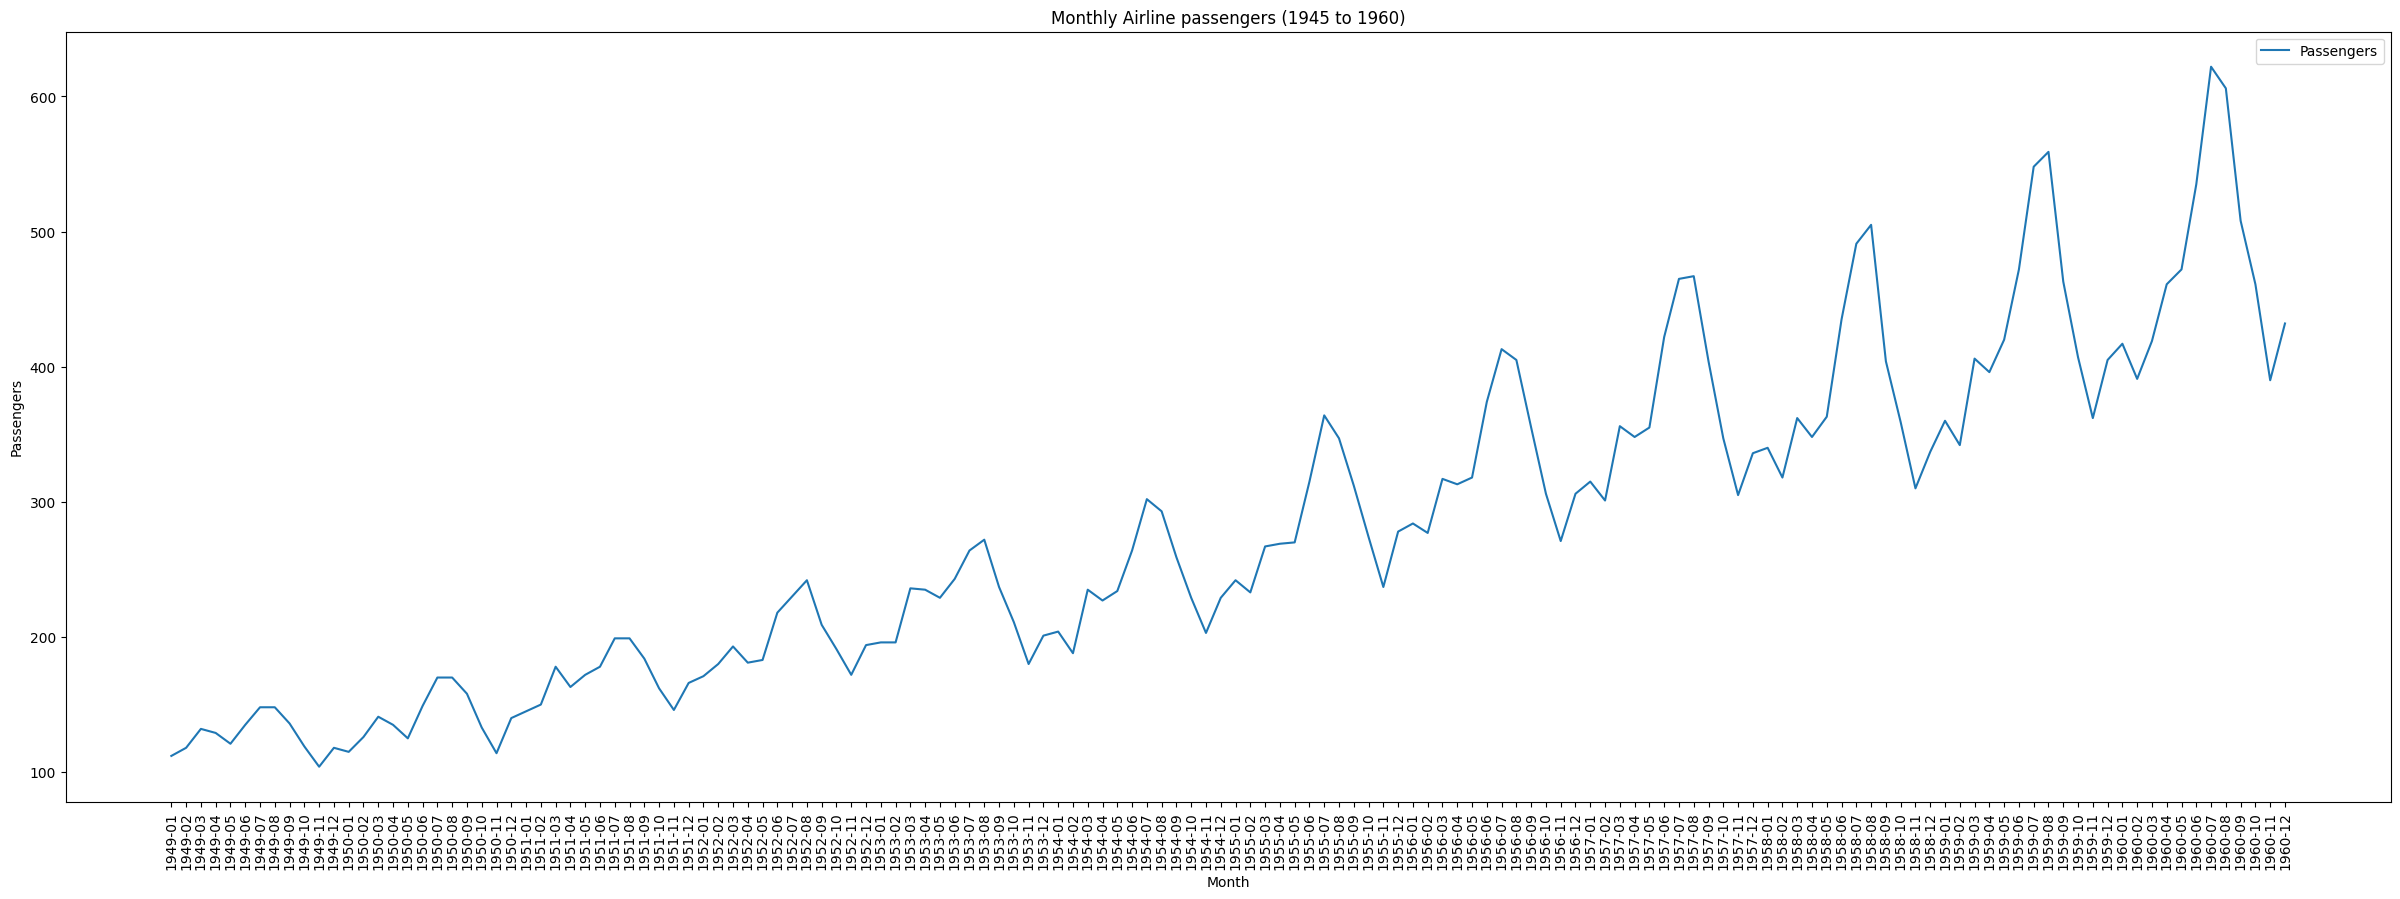

In [17]:
plt.figure(figsize=(30,10))
plt.plot(df["Month"], df["Passengers"], label="Passengers")
plt.title("Monthly Airline passengers (1945 to 1960)")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.xticks(rotation="vertical")
plt.legend()
plt.show()

In [ ]:
# Check for non-stationary (seasonal) data using Augumented Dickey-Fuler test (adfuller)
result = adfuller(df["Passengers"])
p_value = result[1]
adf = result[0]

print(f"P-Value: {p_value:.3f}")
print(f"ADF Stat: {adf:.3f}")

P-Value: 0.992
ADF Stat: 0.815


Null Hypothesis - (H0) --- the data is non-stationary (seasonal) (if (p-value > 0.05) it means the null-hypothesis is rejected and vice versa) (if adf is negative then the data is non-seasonal and vice versa)

Alternate Hypothesis - (H1) -- the data is stationary (non-seasonal)

>inference: The high p-value shows the series is non-stationary, so transformations like differencing or decomposition are required before forecasting

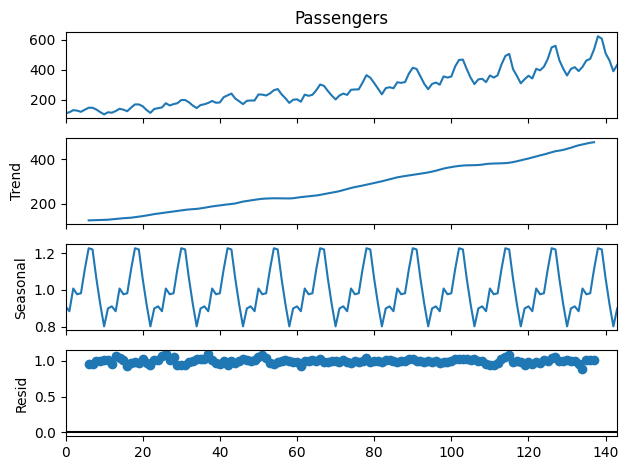

In [24]:
# Seasonal Decomposition
decomp = seasonal_decompose(
    df['Passengers'], 
    model="multiplicative", 
    period=12 # time frame (month)
)
decomp.plot()
plt.show()

data = trend * seasonal * Residuals(errors)

In [25]:
# train test split
train = df.iloc[:-12] # extract all the rows except last 12 rows
test = df.iloc[-12:] # extract last 12 rows

In [26]:
train

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
127,1959-08,559
128,1959-09,463
129,1959-10,407
130,1959-11,362


In [27]:
test

,Month,Passengers
132,1960-01,417
133,1960-02,391
134,1960-03,419
135,1960-04,461
136,1960-05,472
137,1960-06,535
138,1960-07,622
139,1960-08,606
140,1960-09,508
141,1960-10,461


In [28]:
#Train ARIMA moodel
model = ARIMA(train["Passengers"], order=[5,1,0])
trained_model = model.fit()

In [29]:
# getting forecast
forecast = trained_model.forecast(steps=12)

In [30]:
print(forecast)

132    458.449443
133    479.570529
134    480.136847
135    456.665327
136    435.835309
137    431.734529
138    437.928972
139    448.935482
140    455.562127
141    454.628434
142    450.095384
143    445.706018
Name: predicted_mean, dtype: float64


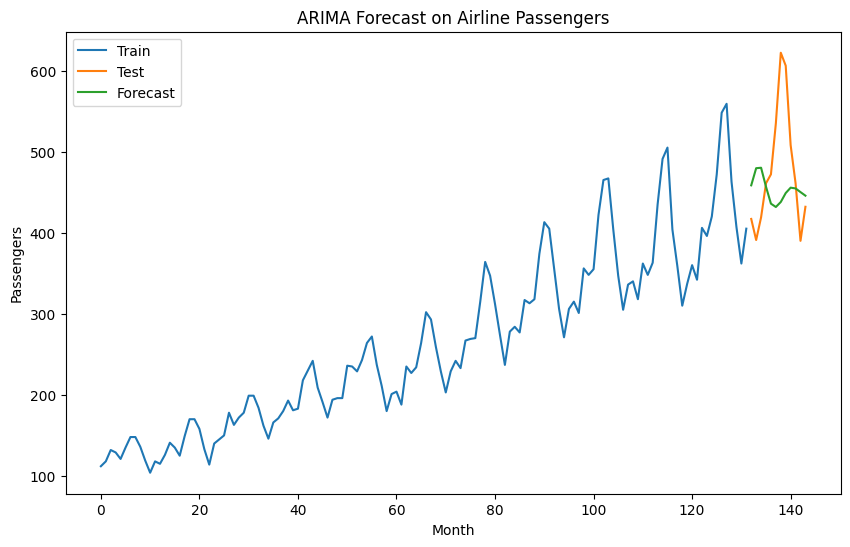

In [33]:
# Plot forecast Vs Actual Values
plt.figure(figsize=(10,6))
plt.plot(train.index, train["Passengers"], label="Train")
plt.plot(test.index, test["Passengers"], label="Test")
plt.plot(test.index, forecast, label="Forecast")
plt.title("ARIMA Forecast on Airline Passengers")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.show()

In [35]:
# error metrics
mae = mean_absolute_error(test["Passengers"], forecast)
mse = mean_squared_error(test["Passengers"], forecast)
rmse = root_mean_squared_error(test["Passengers"], forecast)

print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")

MAE : 67.39
MSE : 7536.00
RMSE : 86.81


In [36]:
# SARIMAX model
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [37]:
# before training the model we have to get the log value
train_log = np.log(train["Passengers"])
test_log = np.log(test["Passengers"])

In [41]:
sarimax_model = SARIMAX(
    train_log,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

# train the model
trained_sarimax_model = sarimax_model.fit(disp=False, maxiter=200)

In [42]:
forecast_log = trained_sarimax_model.forecast(steps=12)
forecast_series = np.exp(forecast_log)

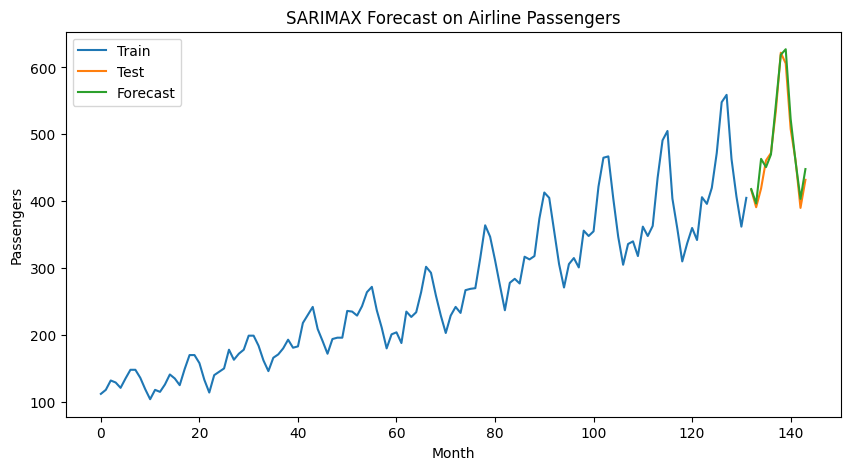

In [43]:
# Plot forecast Vs Actual
plt.figure(figsize=(10,5))
plt.plot(train.index, train["Passengers"], label="Train")
plt.plot(test.index, test["Passengers"], label="Test")
plt.plot(test.index, forecast_series, label="Forecast")
plt.title("SARIMAX Forecast on Airline Passengers")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.show()

In [44]:
# error metrics
mae = mean_absolute_error(test["Passengers"], forecast_series)
mse = mean_squared_error(test["Passengers"], forecast_series)
rmse = root_mean_squared_error(test["Passengers"], forecast_series)

print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")

MAE : 11.98
MSE : 276.61
RMSE : 16.63


**ARIMA**

(AutoRegressive Integrated Moving Average): Predicts future values by removing trend and learning from past values and past errors.

(P, D, Q)
- P -> Past values used
- D -> trend removal
- Q -> past errors used

____

**SARIMAX**

(Seasonal AutoRegresive Integrated Moving Average with eXogeneous variables) : ARIMA extended to learn repeating seasonal patterns and optional external inputs.

Seasonal (P, D, Q, S)
- P,D, Q -> Seasonal memory and corrections
- S -> Seasonal length (12 for monthly data)

_____

Quick rule

- ARIMA -> no seasonality
- SARIMAX -> Seasonality present